# Dataset Split Generator — Step 5

**Goal:**  
Create *patient-disjoint* training and validation splits for the processed dataset,  
ensuring no data leakage and maintaining approximately an 80/20 balance by **patch count**.

---

### What this notebook does
1. Loads patch metadata from the processed dataset.  
2. Computes how many patches belong to each patient.  
3. Selects train/val patients to achieve ~80/20 patch ratio.  
4. Saves train/val split files (`train.csv`, `val.csv`) under `/splits`.  
5. Prints balance and sanity checks.


### Table of Contents
- [Step 1 — Load paths and patch metadata](#step1)
- [Step 2 — Patch Extraction and Label Generation](#step2)
- [Step 3 — Visual Inspection of Generated Patches](#step3)
- [Step 4 — Summary and Quality Checks](#step4)
- [Step 5 — Dataset Integrity + Overview](#step5)

<a id="step1"></a>
## Step 1 — Load paths and patch metadata

In [5]:
from pathlib import Path
import pandas as pd

# --- Configuration ---
DATASET_DIR = Path("/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256")
LABELS_DIR = DATASET_DIR / "labels"
SPLITS_DIR = DATASET_DIR / "splits_801010"
SPLITS_DIR.mkdir(exist_ok=True)

# --- Gather patch info ---
patch_paths = sorted(LABELS_DIR.glob("*.csv"))
records = []

for f in patch_paths:
    stem = f.stem
    # Extract patient ID (before first underscore)
    patient_id = stem.split("_")[0]
    records.append({"patient": patient_id, "patch": stem})

df = pd.DataFrame(records)
print(f"Total patches found: {len(df)}")
print(f"Unique patients: {df['patient'].nunique()}")
display(df.head())


Total patches found: 1106
Unique patients: 74


,patient,patch
0,TCGA-55-1594-01Z-00-DX1,TCGA-55-1594-01Z-00-DX1_001_0_0
1,TCGA-55-1594-01Z-00-DX1,TCGA-55-1594-01Z-00-DX1_001_0_256
2,TCGA-55-1594-01Z-00-DX1,TCGA-55-1594-01Z-00-DX1_001_0_512
3,TCGA-55-1594-01Z-00-DX1,TCGA-55-1594-01Z-00-DX1_001_0_768
4,TCGA-55-1594-01Z-00-DX1,TCGA-55-1594-01Z-00-DX1_001_256_0


<a id="step2"></a>
## Step 2 — Compute per-patient patch counts

Total patches: 1106
Patch count per patient:


patient
TCGA-B9-A8YI-01Z-00-DX1      67
TCGA-E9-A22B-01Z-00-DX1      60
TCGA-S3-AA11-01Z-00-DX1      55
TCGA-D8-A1X5-01Z-00-DX2      50
TCGA-86-8672-01Z-00-DX1      47
                             ..
TCGA-J4-A67Q-01Z-00-DX1-4     1
TCGA-G9-6342-01Z-00-DX1-2     1
TCGA-EJ-5505-01Z-00-DX1-4     1
TCGA-EJ-5505-01Z-00-DX1-2     1
TCGA-YL-A9WY-01Z-00-DX1-4     1
Length: 74, dtype: int64

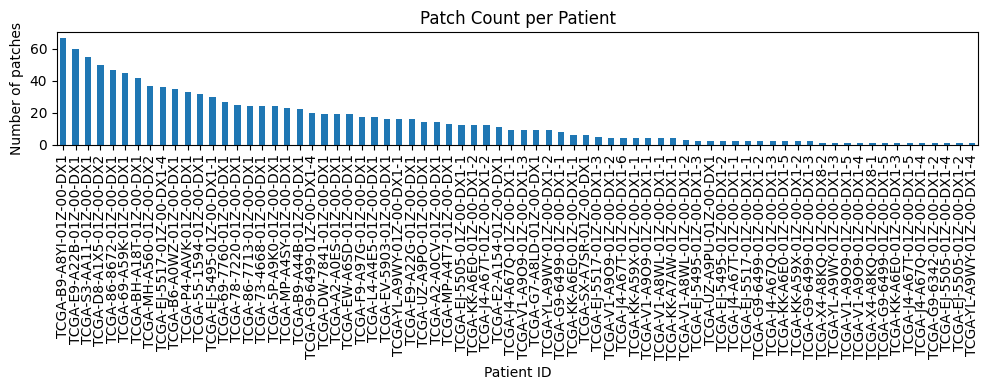

In [3]:
patient_patch_counts = df.groupby("patient").size().sort_values(ascending=False)
total_patches = patient_patch_counts.sum()

print(f"Total patches: {total_patches}")
print("Patch count per patient:")
display(patient_patch_counts)

# Visualize distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
patient_patch_counts.plot(kind="bar")
plt.title("Patch Count per Patient")
plt.xlabel("Patient ID")
plt.ylabel("Number of patches")
plt.tight_layout()
plt.show()


<a id="step3"></a>
## Step 3 — Patient-level 80/10/10 patch-balanced split

In [4]:
# --------------------------------------------------
# Target patch counts per split
# --------------------------------------------------
target_train = 0.8 * total_patches
target_val   = 0.1 * total_patches
target_test  = 0.1 * total_patches

# --------------------------------------------------
# Greedy patient assignment
# --------------------------------------------------
splits = {
    "train": {"patients": [], "count": 0, "target": target_train},
    "val":   {"patients": [], "count": 0, "target": target_val},
    "test":  {"patients": [], "count": 0, "target": target_test},
}

for patient, count in patient_patch_counts.items():
    # assign to the split with the most remaining capacity
    remaining = {
        k: v["target"] - v["count"]
        for k, v in splits.items()
    }
    # choose split with max remaining capacity
    split_name = max(remaining, key=remaining.get)

    splits[split_name]["patients"].append(patient)
    splits[split_name]["count"] += count

# --------------------------------------------------
# Summary
# --------------------------------------------------
print("\n=== Split summary (by patches) ===")
for name, info in splits.items():
    ratio = info["count"] / total_patches
    print(
        f"{name.upper():5s}: "
        f"{len(info['patients']):3d} patients | "
        f"{info['count']:6d} patches | "
        f"{ratio:.1%}"
    )


=== Split summary (by patches) ===
TRAIN:  40 patients |    885 patches | 80.0%
VAL  :  17 patients |    111 patches | 10.0%
TEST :  17 patients |    110 patches | 9.9%


<a id="step4"></a>
## Step 4 — Save train/val patch lists

In [6]:
# --------------------------------------------------
# Save patch lists
# --------------------------------------------------
for name, info in splits.items():
    patches = df[df["patient"].isin(info["patients"])]["patch"]
    out_path = SPLITS_DIR / f"fold_{name}.csv"
    patches.to_csv(out_path, index=False, header=False)
    print(f"Saved {out_path} ({len(patches)} patches)")

Saved /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256/splits_801010/fold_train.csv (885 patches)
Saved /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256/splits_801010/fold_val.csv (111 patches)
Saved /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256/splits_801010/fold_test.csv (110 patches)


<a id="step5"></a>
## Step 5 — Verify patch and class balance

In [7]:
# --------------------------------------------------
# Patch & patient counts per split
# --------------------------------------------------
split_patch_counts = {}
split_patient_counts = {}

for name, info in splits.items():
    patches = df[df["patient"].isin(info["patients"])]
    split_patch_counts[name] = len(patches)
    split_patient_counts[name] = len(info["patients"])
print("\n=== Patch distribution summary ===")
for name in ["train", "val", "test"]:
    ratio = split_patch_counts[name] / total_patches
    print(
        f"{name.upper():5s}: "
        f"{split_patient_counts[name]:3d} patients | "
        f"{split_patch_counts[name]:4d} patches | "
        f"{ratio:.1%}"
    )



=== Patch distribution summary ===
TRAIN:  40 patients |  885 patches | 80.0%
VAL  :  17 patients |  111 patches | 10.0%
TEST :  17 patients |  110 patches | 9.9%


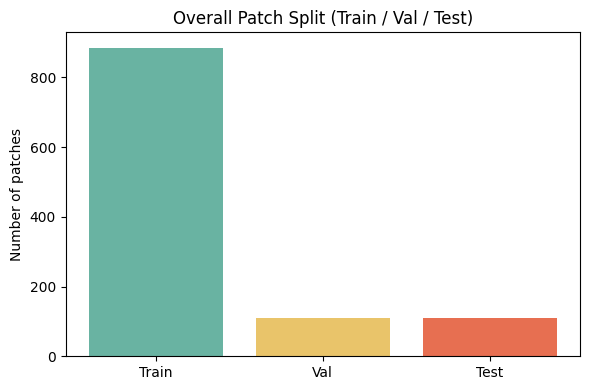

In [8]:
import matplotlib.pyplot as plt

labels = ["Train", "Val", "Test"]
values = [
    split_patch_counts["train"],
    split_patch_counts["val"],
    split_patch_counts["test"],
]

colors = ["#69b3a2", "#e9c46a", "#e76f51"]

plt.figure(figsize=(6,4))
plt.bar(labels, values, color=colors)
plt.ylabel("Number of patches")
plt.title("Overall Patch Split (Train / Val / Test)")
plt.tight_layout()
plt.show()


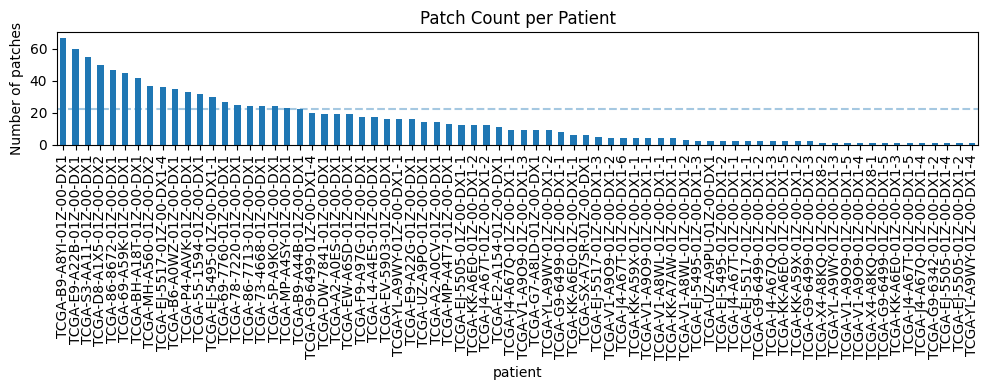

In [9]:
plt.figure(figsize=(10,4))
patient_patch_counts.plot(kind="bar")
plt.axhline(y=target_train/len(splits["train"]["patients"]), linestyle="--", alpha=0.4)
plt.title("Patch Count per Patient")
plt.ylabel("Number of patches")
plt.tight_layout()
plt.show()


In [13]:
from pathlib import Path
import shutil
import pandas as pd

# --------------------------------------------------
# Paths
# --------------------------------------------------
DATASET_DIR = Path(
    "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/"
    "AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/"
    "ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256"
)

IMAGES_DIR = DATASET_DIR / "images"
CSV_LABELS_SRC = DATASET_DIR / "labels"              # CSV nucleus labels
MAP_LABELS_SRC = DATASET_DIR / "patch_label_maps"    # .npy label maps
SPLITS_DIR = DATASET_DIR / "splits_801010"

assert IMAGES_DIR.exists()
assert CSV_LABELS_SRC.exists()
assert MAP_LABELS_SRC.exists()
assert SPLITS_DIR.exists()

# --------------------------------------------------
# Split → fold mapping
# --------------------------------------------------
FOLD_MAP = {
    "fold_train.csv": "fold0",
    "fold_val.csv":   "fold1",
    "fold_test.csv":  "fold2",
}

# --------------------------------------------------
# Materialize folds
# --------------------------------------------------
for split_csv, fold_name in FOLD_MAP.items():
    split_path = SPLITS_DIR / split_csv
    fold_dir = DATASET_DIR / fold_name

    # Create fold subdirs
    images_dst = fold_dir / "images"
    csv_dst    = fold_dir / "csv_labels"
    labels_dst = fold_dir / "labels"

    images_dst.mkdir(parents=True, exist_ok=True)
    csv_dst.mkdir(parents=True, exist_ok=True)
    labels_dst.mkdir(parents=True, exist_ok=True)

    patches = pd.read_csv(split_path, header=None)[0].tolist()

    n_img = n_csv = n_npy = 0

    for patch in patches:
        # -------------------
        # Image (.png)
        # -------------------
        img_src = IMAGES_DIR / f"{patch}.png"
        if img_src.exists():
            dst = images_dst / img_src.name
            if not dst.exists():
                shutil.copy2(img_src, dst)
            n_img += 1
        else:
            print(f"⚠️ Missing image: {img_src}")

        # -------------------
        # CSV nucleus labels
        # -------------------
        csv_src = CSV_LABELS_SRC / f"{patch}.csv"
        if csv_src.exists():
            dst = csv_dst / csv_src.name
            if not dst.exists():
                shutil.copy2(csv_src, dst)
            n_csv += 1
        else:
            print(f"⚠️ Missing csv label: {csv_src}")

        # -------------------
        # Patch label maps (.npy)
        # -------------------
        npy_src = MAP_LABELS_SRC / f"{patch}.npy"
        if npy_src.exists():
            dst = labels_dst / npy_src.name
            if not dst.exists():
                shutil.copy2(npy_src, dst)
            n_npy += 1
        else:
            print(f"⚠️ Missing npy label map: {npy_src}")

    print(
        f"✅ {fold_name}: "
        f"{n_img} images | {n_csv} csv_labels | {n_npy} label_maps"
    )


✅ fold0: 885 images | 885 csv_labels | 885 label_maps
✅ fold1: 111 images | 111 csv_labels | 111 label_maps
✅ fold2: 110 images | 110 csv_labels | 110 label_maps


In [14]:
for fold in ["fold0", "fold1", "fold2"]:
    fdir = DATASET_DIR / fold
    print(
        fold,
        len(list((fdir / "images").glob("*.png"))),
        len(list((fdir / "csv_labels").glob("*.csv"))),
        len(list((fdir / "labels").glob("*.npy")))
    )


fold0 885 885 885
fold1 111 111 111
fold2 110 110 110


# Validation

In [15]:
import pandas as pd
from pathlib import Path
from collections import Counter, defaultdict

BASE_DIR = DATASET_DIR  # reuse from before
FOLDS = ["fold0", "fold1", "fold2"]

# --------------------------------------------------
# 1) Collect patch + patient info per fold
# --------------------------------------------------
fold_patches = {}
fold_patients = {}

for fold in FOLDS:
    img_dir = BASE_DIR / fold / "images"
    patches = sorted(p.stem for p in img_dir.glob("*.png"))
    fold_patches[fold] = set(patches)

    patients = {p.split("_")[0] for p in patches}
    fold_patients[fold] = patients

# --------------------------------------------------
# 2) Check patch leakage
# --------------------------------------------------
print("=== Patch leakage check ===")
for i, f1 in enumerate(FOLDS):
    for f2 in FOLDS[i+1:]:
        overlap = fold_patches[f1] & fold_patches[f2]
        print(f"{f1} vs {f2}: overlap = {len(overlap)}")
        assert len(overlap) == 0

print("✔ No patch leakage\n")

# --------------------------------------------------
# 3) Check patient leakage
# --------------------------------------------------
print("=== Patient leakage check ===")
for i, f1 in enumerate(FOLDS):
    for f2 in FOLDS[i+1:]:
        overlap = fold_patients[f1] & fold_patients[f2]
        print(f"{f1} vs {f2}: shared patients = {len(overlap)}")
        assert len(overlap) == 0

print("✔ No patient leakage\n")

# --------------------------------------------------
# 4) Cell-type distribution per fold
# --------------------------------------------------
print("=== Cell-type distribution ===")

fold_cell_counts = {}

for fold in FOLDS:
    csv_dir = BASE_DIR / fold / "csv_labels"
    counter = Counter()

    for csv_file in csv_dir.glob("*.csv"):
        df = pd.read_csv(csv_file, header=None)
        if df.shape[1] >= 3:
            counter.update(df.iloc[:, 2].astype(int).tolist())

    fold_cell_counts[fold] = counter

    total_cells = sum(counter.values())
    print(f"\n{fold} (total nuclei = {total_cells}):")
    for cls, cnt in sorted(counter.items()):
        print(f"  class {cls}: {cnt} ({cnt/total_cells:.1%})")

# --------------------------------------------------
# 5) Compare distributions (rough balance)
# --------------------------------------------------
print("\n=== Relative cell-type ratios per fold ===")
all_classes = sorted(
    set().union(*[c.keys() for c in fold_cell_counts.values()])
)

for cls in all_classes:
    ratios = []
    for fold in FOLDS:
        total = sum(fold_cell_counts[fold].values())
        ratios.append(
            fold_cell_counts[fold][cls] / total if total > 0 else 0
        )
    print(f"class {cls}: " + " | ".join(f"{r:.2%}" for r in ratios))


=== Patch leakage check ===
fold0 vs fold1: overlap = 0
fold0 vs fold2: overlap = 0
fold1 vs fold2: overlap = 0
✔ No patch leakage

=== Patient leakage check ===
fold0 vs fold1: shared patients = 0
fold0 vs fold2: shared patients = 0
fold1 vs fold2: shared patients = 0
✔ No patient leakage

=== Cell-type distribution ===

fold0 (total nuclei = 19261):
  class 1: 10810 (56.1%)
  class 2: 7974 (41.4%)
  class 3: 285 (1.5%)
  class 4: 192 (1.0%)

fold1 (total nuclei = 4159):
  class 1: 1498 (36.0%)
  class 2: 2555 (61.4%)
  class 3: 66 (1.6%)
  class 4: 40 (1.0%)

fold2 (total nuclei = 3472):
  class 1: 1828 (52.6%)
  class 2: 1501 (43.2%)
  class 3: 113 (3.3%)
  class 4: 30 (0.9%)

=== Relative cell-type ratios per fold ===
class 1: 56.12% | 36.02% | 52.65%
class 2: 41.40% | 61.43% | 43.23%
class 3: 1.48% | 1.59% | 3.25%
class 4: 1.00% | 0.96% | 0.86%


Create types

In [16]:
import csv
from pathlib import Path

# --------------------------------------------------
# Base directory (same one you used for folds)
# --------------------------------------------------
BASE_DIR = DATASET_DIR  # reuse from previous cells

FOLDS = ["fold0", "fold1", "fold2"]
TISSUE_NAME = "Lung"

# --------------------------------------------------
# Create types.csv for each fold
# --------------------------------------------------
for fold in FOLDS:
    fold_dir = BASE_DIR / fold
    images_dir = fold_dir / "images"
    assert images_dir.exists(), f"Missing images dir: {images_dir}"

    image_files = sorted(p.name for p in images_dir.glob("*.png"))
    if not image_files:
        print(f"⚠️ No images found in {images_dir}")
        continue

    types_csv = fold_dir / "types.csv"

    with open(types_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["img", "type"])
        for img_name in image_files:
            writer.writerow([img_name, TISSUE_NAME])

    print(f"✅ {fold}: created types.csv with {len(image_files)} entries")


✅ fold0: created types.csv with 885 entries
✅ fold1: created types.csv with 111 entries
✅ fold2: created types.csv with 110 entries
